# Análisis de Ventas: Optimización de Inventario mediante Principio de Pareto

## Introducción
En este proyecto se analiza el conjunto de datos `SampleSuperstore` con el objetivo de identificar las categorías de productos que generan el mayor impacto financiero para la empresa. 

Utilizaremos la **Regla de Pareto (80/20)**, la cual sugiere que aproximadamente el 80% de las ventas provienen del 20% de las subcategorías. Identificar estos productos es crucial para la toma de decisiones estratégicas, como la gestión de stock y la asignación de presupuestos de marketing.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('SampleSuperstore.csv')
## 1. Exploración Inicial
#En esta sección cargamos los datos y verificamos la integridad del dataset (tipos de datos y valores nulos) para asegurar un análisis preciso.
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB
None


## 2. Procesamiento y Cálculo de Pareto
Para determinar el impacto de cada subcategoría, realizamos los siguientes pasos:
1. Agrupamos las ventas totales por **Sub-Category**.
2. Calculamos el peso porcentual de cada una respecto al total.
3. Obtenemos el **porcentaje acumulado** para identificar el punto de corte del 80%.

In [27]:
pareto_df = df.groupby('Sub-Category')['Sales'].sum().reset_index()
pareto_df = pareto_df.sort_values(by='Sales', ascending=False)
pareto_df['Porcentajes'] = (pareto_df['Sales'] / pareto_df['Sales'].sum()) * 100
pareto_df['Cum_Percentage'] = pareto_df['Porcentajes'].cumsum()
pareto_df = pareto_df.reset_index()
pareto_df.drop(['index'], axis=1, inplace=True)
print(pareto_df) 
mas_impacto= pareto_df[pareto_df['Cum_Percentage'] <= 80]
menos_impacto = pareto_df[pareto_df['Cum_Percentage'] > 80]
print(mas_impacto)

   Sub-Category        Sales  Porcentajes  Cum_Percentage
0        Phones  330007.0540    14.365616       14.365616
1        Chairs  328449.1030    14.297796       28.663412
2       Storage  223843.6080     9.744190       38.407602
3        Tables  206965.5320     9.009466       47.417068
4       Binders  203412.7330     8.854808       56.271876
5      Machines  189238.6310     8.237792       64.509669
6   Accessories  167380.3180     7.286273       71.795941
7       Copiers  149528.0300     6.509140       78.305082
8     Bookcases  114879.9963     5.000869       83.305950
9    Appliances  107532.1610     4.681008       87.986958
10  Furnishings   91705.1640     3.992039       91.978998
11        Paper   78479.2060     3.416297       95.395295
12     Supplies   46673.5380     2.031757       97.427052
13          Art   27118.7920     1.180515       98.607567
14    Envelopes   16476.4020     0.717238       99.324805
15       Labels   12486.3120     0.543545       99.868349
16    Fastener

### Hallazgos Principales
Tras procesar los datos, observamos que **8 de las 17 subcategorías** representan el **78.3%** de las ventas totales. Esto valida la hipótesis de Pareto en nuestro modelo de negocio.

Las categorías con mayor impacto son:
* **Tecnología y Muebles:** Phones, Chairs y Storage lideran la lista.
* **Maquinaria:** Aunque son menos frecuentes, su alto costo las posiciona rápidamente en el acumulado.

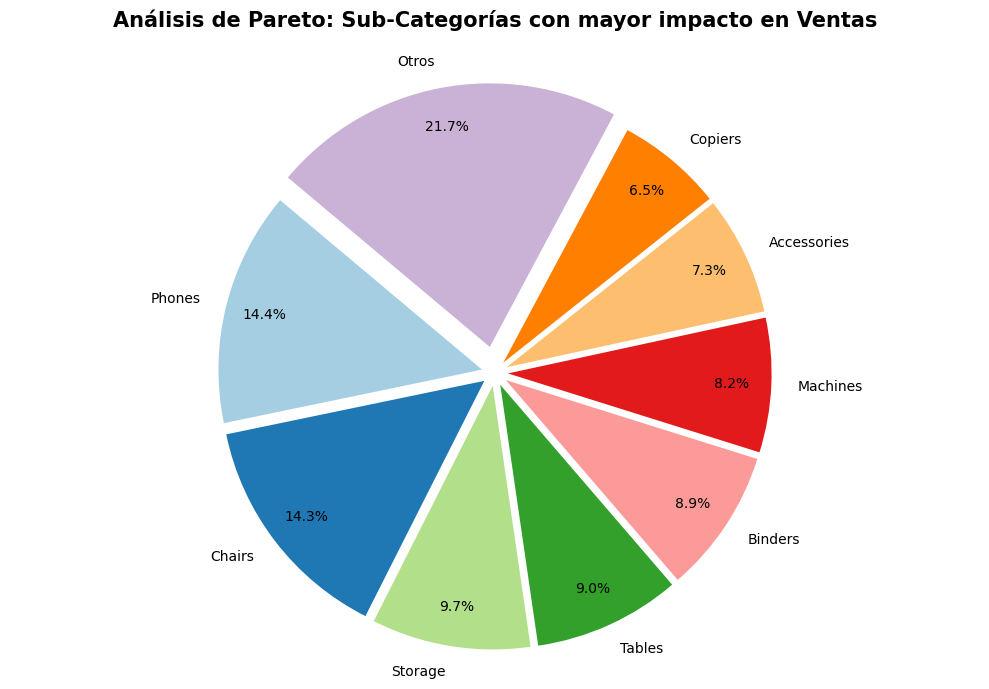

In [28]:
sales_data = mas_impacto['Sales'].tolist() + [menos_impacto['Sales'].sum()]
labels = mas_impacto['Sub-Category'].tolist() + ['Otros']
plt.figure(figsize=(10, 7)) #Define el tamaño de la ventana
colors = plt.cm.Paired(range(len(labels))) #Genera automáticamente una paleta de colores distintos
plt.pie(sales_data, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        pctdistance=0.85,
        explode=[0.05] * len(mas_impacto['Sales']) + [0.1]) 
plt.title('Análisis de Pareto: Sub-Categorías con mayor impacto en Ventas', 
          fontsize=15, 
          pad=20, 
          fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show() 

## 3. Visualización de Resultados
El siguiente gráfico ilustra la distribución de las ventas. La categoría **"Otros"** agrupa el 21.7% restante distribuido en las 9 subcategorías de menor rotación.

### Conclusiones y Recomendaciones
1. **Priorización de Stock:** Se recomienda mantener un nivel de inventario óptimo (Safety Stock) para las categorías del grupo "Más Impacto" para evitar pérdidas por falta de producto.
2. **Estrategia de Ventas:** Analizar si la categoría "Otros" puede reducirse para optimizar costos de almacenamiento sin afectar la variedad ofrecida al cliente.
3. **Foco Estratégico:** Phones y Chairs por sí solos generan casi el 30% de la ganancia; cualquier mejora en el margen de estos productos tendrá un impacto masivo en el resultado global.

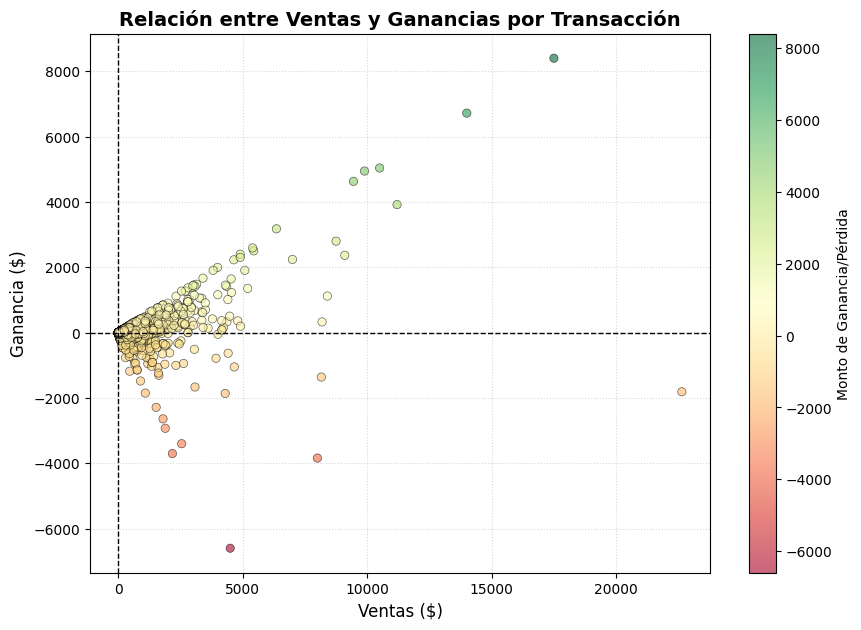

In [29]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(
    df['Sales'],
    df['Profit'],
    c=df['Profit'],
    cmap='RdYlGn',       # Mapa de Rojo (pérdida) a Verde (ganancia)
    alpha=0.6, 
    marker='o',          # 'o' suele ser más limpio que 'P' para muchos datos
    edgecolors='black',
    linewidth=0.5
)
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea en Profit 0
plt.axvline(0, color='black', linestyle='--', linewidth=1) # Línea en Sales 0

plt.colorbar(scatter, label='Monto de Ganancia/Pérdida')

plt.title('Relación entre Ventas y Ganancias por Transacción', fontsize=14, fontweight='bold')
plt.xlabel('Ventas ($)', fontsize=12)
plt.ylabel('Ganancia ($)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

## Conclusiones y Recomendaciones Finales

Tras el análisis integral de las ventas y beneficios de `SampleSuperstore`, se concluye lo siguiente:

1. **Priorización de Inventario:** El éxito del negocio depende de una gestión impecable del stock en las categorías de mayor impacto (Phones y Chairs). Una ruptura de stock en estos artículos tendría consecuencias devastadoras para el ingreso mensual.
2. **Revisión de Política de Descuentos:** El análisis de dispersión sugiere que los descuentos agresivos están destruyendo el valor en transacciones grandes. Se recomienda establecer un sistema de alertas para cualquier venta que genere un margen de ganancia negativo.
3. **Siguiente Fase del Análisis:** Para profundizar en la causa raíz de las pérdidas, el próximo paso será analizar la relación entre la columna `Discount` y el `Profit`, segmentado por `Region`, para determinar si el problema es logístico o comercial.

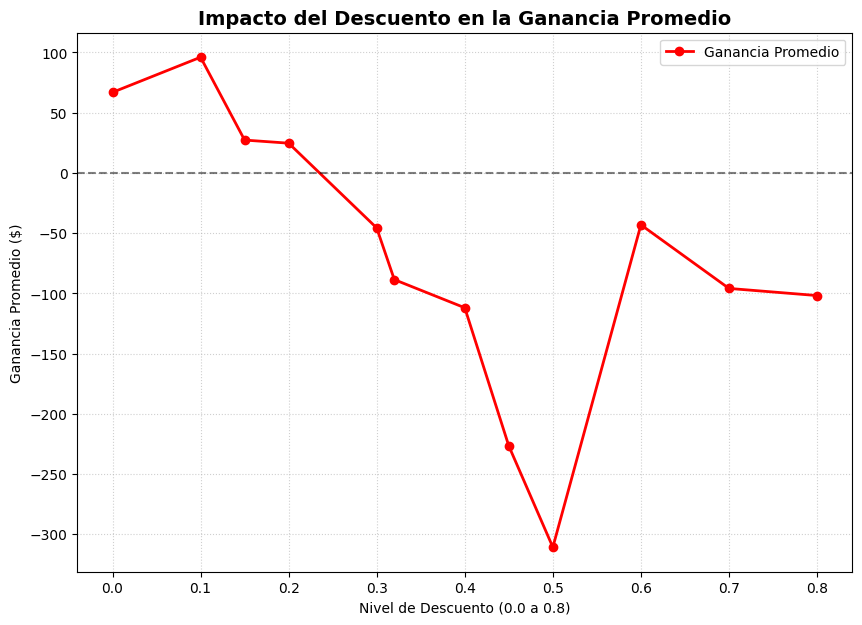

In [33]:

plt.figure(figsize=(10,7))
d0 = df[df['Discount'] == 0.0]['Profit']
d20 = df[df['Discount'] == 0.2]['Profit']
d50 = df[df['Discount'] == 0.5]['Profit']
descuento_analisis = df.groupby('Discount')['Profit'].mean().reset_index()

plt.plot(
    descuento_analisis['Discount'], 
    descuento_analisis['Profit'], 
    color='red', 
    marker='o', 
    linewidth=2, 
    label='Ganancia Promedio'
)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Impacto del Descuento en la Ganancia Promedio', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Descuento (0.0 a 0.8)')
plt.ylabel('Ganancia Promedio ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()




### Análisis del Impacto del Descuento en la Rentabilidad Promedio
Al observar la tendencia de las ganancias en función del descuento aplicado, se identifican tres zonas críticas:

1. **Zona de Rentabilidad (0% - 20%):** Los descuentos bajos permiten mantener un margen de beneficio positivo. Curiosamente, el punto máximo de ganancia promedio se alcanza con un **10% de descuento**, lo que sugiere que pequeños incentivos impulsan ventas saludables.
2. **El Punto de Quiebre (Umbral del 20%):** A partir del 20% de descuento, la rentabilidad cae en picada. Cruzar este umbral significa, en promedio, transaccionar con pérdidas.
3. **Zona de Pérdida Crítica (30% - 80%):** Todos los niveles de descuento superiores al 20% resultan en ganancias negativas. El punto más bajo se encuentra en el **50% de descuento**, donde la pérdida promedio supera los **$300 USD** por transacción.

C:\Users\luis\AppData\Local\Temp\ipykernel_22444\4192950543.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


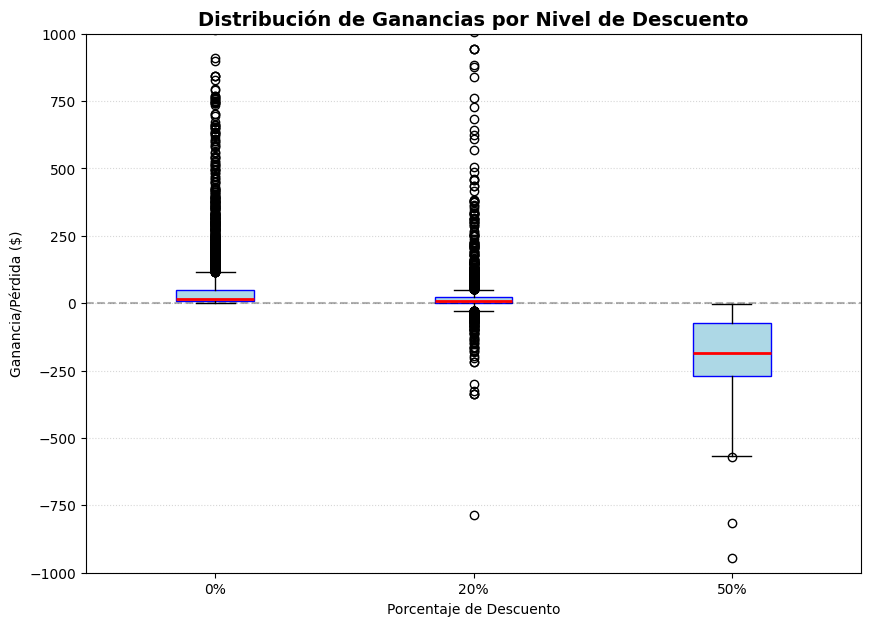

In [35]:
# 1. Preparamos los datos crudos (sin promedios) para cada categoría
# Esto extrae TODOS los beneficios individuales para esos descuentos
d0 = df[df['Discount'] == 0.0]['Profit']
d20 = df[df['Discount'] == 0.2]['Profit']
d50 = df[df['Discount'] == 0.5]['Profit']

# 2. Los agrupamos en una lista
datos_para_graficar = [d0, d20, d50]

# 3. Creamos la figura
plt.figure(figsize=(10, 7))

# 4. Graficamos pasándole la lista de los tres grupos
plt.boxplot(
    datos_para_graficar, 
    labels=["0%", "20%", "50%"],
    patch_artist=True, 
    boxprops=dict(facecolor='lightblue', color='blue'),
    medianprops=dict(color='red', linewidth=2)
)

# Estética y etiquetas
plt.title('Distribución de Ganancias por Nivel de Descuento', fontsize=14, fontweight='bold')
plt.ylabel('Ganancia/Pérdida ($)')
plt.xlabel('Porcentaje de Descuento')

# Línea en 0 para identificar fácilmente las pérdidas
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

# Limitamos el eje Y para que los valores extremos no "aplasten" las cajas
plt.ylim(-1000, 1000) 

plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.show()

### Distribución y Riesgo Financiero por Nivel de Descuento
Mientras que el gráfico de líneas nos dio el promedio, el Boxplot nos revela la realidad operativa detrás de esos números:

* **0% de Descuento (Estabilidad):** La caja es compacta y se sitúa casi totalmente por encima de la línea de cero. Existe una gran cantidad de valores atípicos (outliers) positivos, lo que indica transacciones altamente rentables.
* **20% de Descuento (Inestabilidad):** Aquí la mediana (línea roja) está rozando el cero. Aunque algunas ventas son rentables, empezamos a ver una dispersión importante hacia las pérdidas. Es una zona de alto riesgo.
* **50% de Descuento (Pérdida Sistemática):** La interpretación aquí es contundente: **Casi el 100% de la caja está por debajo de la línea de cero.** Esto significa que no es un error aleatorio; el modelo de ventas con 50% de descuento está diseñado para perder dinero. Los "bigotes" y valores atípicos negativos muestran pérdidas de hasta $1,000 USD en una sola venta.